# Análisis de Evasión de Clientes (Churn) – Telecom X

## Contexto
La empresa Telecom X enfrenta un alto nivel de cancelación de clientes. Este fenómeno, conocido como **Churn**, representa un desafío importante para el negocio, ya que implica pérdida de ingresos y mayores costos de adquisición de nuevos clientes.

## Objetivo del análisis
El objetivo de este proyecto es analizar los datos de clientes para identificar patrones asociados con la evasión y comprender qué factores pueden influir en la decisión de cancelar el servicio.

Para ello se realizó un proceso de:
- Extracción de datos
- Transformación y limpieza
- Análisis exploratorio
- Generación de insights y recomendaciones

#📌 Extracción

####En esta etapa se realizó la obtención de los datos de Telecom X. Los datos fueron cargados desde el archivo JSON y convertidos a un DataFrame de pandas para facilitar su manipulación y análisis.

In [153]:
import pandas as pd

df = pd.read_json("/content/TelecomX_Data.json")
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [154]:
with open("/content/TelecomX_diccionario.md", "r") as f:
    print(f.read())

#### Diccionario de datos

- `customerID`: número de identificación único de cada cliente
- `Churn`: si el cliente dejó o no la empresa
- `gender`: género (masculino y femenino)
- `SeniorCitizen`: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
- `Partner`: si el cliente tiene o no una pareja
- `Dependents`: si el cliente tiene o no dependientes
- `tenure`: meses de contrato del cliente
- `PhoneService`: suscripción al servicio telefónico
- `MultipleLines`: suscripción a más de una línea telefónica
- `InternetService`: suscripción a un proveedor de internet
- `OnlineSecurity`: suscripción adicional de seguridad en línea
- `OnlineBackup`: suscripción adicional de respaldo en línea
- `DeviceProtection`: suscripción adicional de protección del dispositivo
- `TechSupport`: suscripción adicional de soporte técnico, menor tiempo de espera
- `StreamingTV`: suscripción de televisión por cable
- `StreamingMovies`: suscripción de streaming de películas
- `Contract`: t

#🔧 Transformación

In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


### Corrección de inconsistencias

Tras la revisión de la calidad de los datos, no se identificaron valores ausentes en el dataset. Sin embargo, se observó que varias columnas (`customer`, `phone`, `internet` y `account`) contienen estructuras anidadas.



In [156]:
customer = pd.json_normalize(df['customer'])
phone = pd.json_normalize(df['phone'])
internet = pd.json_normalize(df['internet'])
account = pd.json_normalize(df['account'])

In [157]:
df_final = pd.concat(
    [df[['customerID','Churn']], customer, phone, internet, account],
    axis=1
)

df_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [158]:
df_final["Cuentas_Diarias"] = df_final["Charges.Monthly"] / 30

In [159]:
df_final[["Charges.Monthly","Cuentas_Diarias"]].head()

,Charges.Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


Se creó la columna **Cuentas_Diarias** a partir de la facturación mensual (`Charges.Monthly`), dividiendo su valor por 30. Esta nueva variable permite estimar el gasto diario de cada cliente y aporta una visión más detallada para el análisis.

In [160]:
cols_binarias = [
    "Partner","Dependents","PhoneService","PaperlessBilling",
    "OnlineSecurity","OnlineBackup","DeviceProtection",
    "TechSupport","StreamingTV","StreamingMovies","MultipleLines"
]

df_final[cols_binarias] = df_final[cols_binarias].replace({"Yes":1, "No":0})

/tmp/ipykernel_140/51232446.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_final[cols_binarias] = df_final[cols_binarias].replace({"Yes":1, "No":0})


In [161]:
df_final[cols_binarias].head()

,Partner,Dependents,PhoneService,PaperlessBilling,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
0,1,1,1,1,0,1,0,1,1,0,0
1,0,0,1,0,0,0,0,0,0,1,1
2,0,0,1,1,0,0,1,0,0,0,0
3,1,0,1,1,0,1,1,0,1,1,0
4,1,0,1,1,0,0,0,1,1,0,0


Se estandarizaron variables categóricas que contenían valores Yes/No, convirtiéndolas a 1 y 0 para facilitar el análisis y el procesamiento de los datos.

#📊 Carga y análisis

In [162]:
df_final.describe()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Cuentas_Diarias
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.162653,0.484106,0.300124,32.346498,0.902711,0.593230,64.720098,2.157337
std,0.369074,0.499782,0.458343,24.571773,0.296371,0.491265,30.129572,1.004319
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.608333
25%,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.425000,1.180833
50%,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.300000,2.343333
75%,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.875000,2.995833
max,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,3.958333


Se realizó un análisis descriptivo del dataset utilizando la función `describe()` de pandas.  
Esto permitió observar métricas estadísticas como media, desviación estándar, valores mínimos y máximos, así como percentiles que ayudan a comprender la distribución de las variables y el comportamiento general de los clientes.

### Distribución de Churn
Visualización de la proporción de clientes que permanecen en la empresa frente a aquellos que cancelaron el servicio.

In [163]:
df_final["Churn"] = df_final["Churn"].replace({1: "Canceló", 0: "Permanece"})

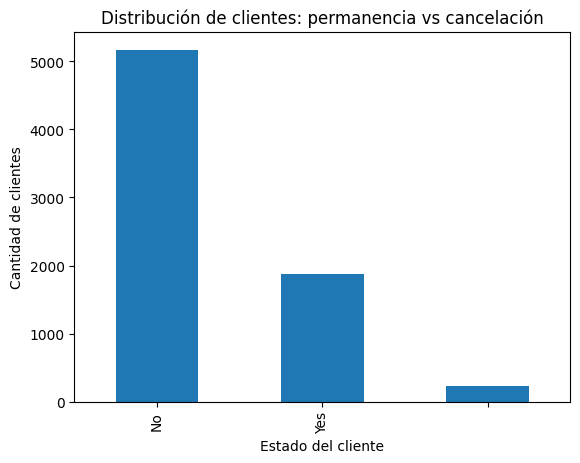

In [164]:
import matplotlib.pyplot as plt

df_final["Churn"].value_counts().plot(kind="bar")
plt.title("Distribución de clientes: permanencia vs cancelación")
plt.xlabel("Estado del cliente")
plt.ylabel("Cantidad de clientes")
plt.show()

Los contratos mensuales tienden a presentar una mayor tasa de cancelación en comparación con los contratos de mayor duración.

In [165]:
df_final["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869
,224


In [166]:
df_final["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,71.198569
Yes,25.719004
,3.082427


### Churn según género
Comparación de la evasión de clientes entre hombres y mujeres.

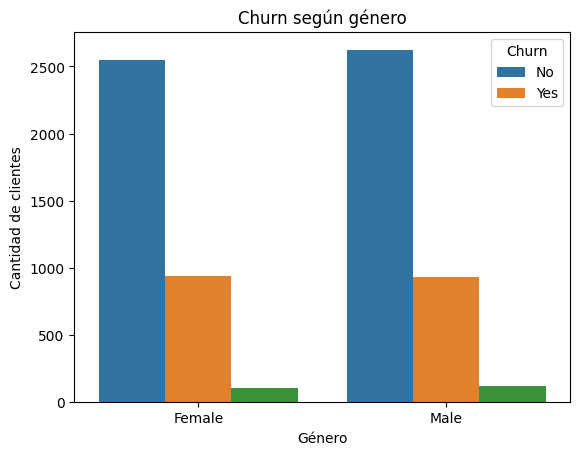

In [167]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df_final, x="gender", hue="Churn")

plt.title("Churn según género")
plt.xlabel("Género")
plt.ylabel("Cantidad de clientes")

plt.show()

Se analizó la distribución de la evasión de clientes según el género.  
Esta visualización permite identificar si existe alguna diferencia en la tasa de cancelación entre hombres y mujeres.

### Churn según tipo de contrato
Análisis de la relación entre el tipo de contrato y la cancelación del servicio.

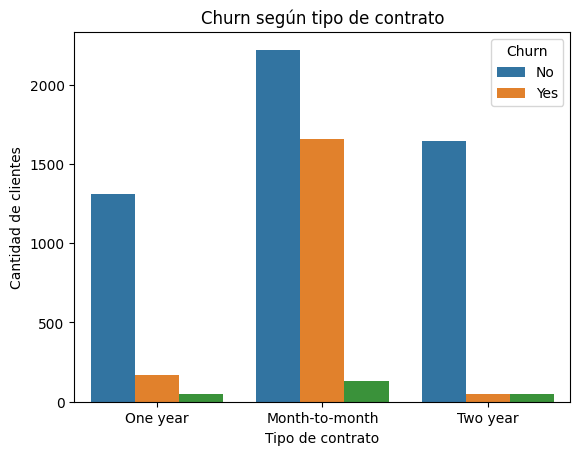

In [168]:
sns.countplot(data=df_final, x="Contract", hue="Churn")

plt.title("Churn según tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Cantidad de clientes")

plt.show()

Los contratos mensuales tienden a presentar una mayor tasa de cancelación en comparación con los contratos de mayor duración.

### Tiempo de permanencia vs Churn
Análisis del tiempo de permanencia de los clientes en relación con la evasión.

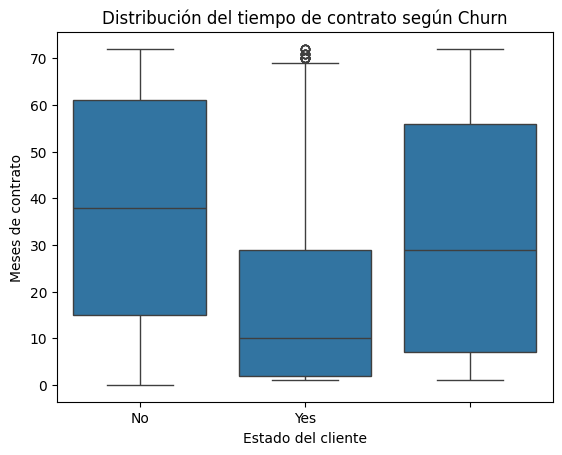

In [169]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df_final, x="Churn", y="tenure")

plt.title("Distribución del tiempo de contrato según Churn")
plt.xlabel("Estado del cliente")
plt.ylabel("Meses de contrato")

plt.show()

Se analizó la distribución del tiempo de contrato (`tenure`) en relación con la evasión de clientes. Este análisis permite observar si los clientes con menor antigüedad presentan mayor tendencia a cancelar el servicio.

#📄Informe final


#  Análisis de Churn

## Introducción
El objetivo de este análisis fue comprender los factores asociados a la evasión de clientes (Churn) en Telecom X. Identificar estos patrones permite a la empresa mejorar sus estrategias de retención y reducir la cancelación de servicios.

## Limpieza y tratamiento de datos
Los datos fueron cargados desde un archivo JSON y transformados en un DataFrame de pandas.  
Se normalizaron columnas anidadas, se verificaron valores nulos y se crearon nuevas variables como **Cuentas_Diarias** para facilitar el análisis.

## Análisis exploratorio
Se analizaron variables categóricas y numéricas mediante visualizaciones.  
Los gráficos permitieron observar la distribución del churn, su relación con el tipo de contrato, el género y el tiempo de permanencia de los clientes.

## Conclusiones y recomendaciones
Los resultados muestran que los clientes con **contratos mensuales** y **menor tiempo de permanencia** presentan mayor probabilidad de cancelación.  

Para reducir el churn se recomienda:
- Incentivar contratos de mayor duración.
- Implementar estrategias de fidelización para clientes nuevos.
- Ofrecer paquetes de servicios que aumenten el valor percibido por el cliente.

#🔧 EXTRA

In [170]:
df_final.corr(numeric_only=True)

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Cuentas_Diarias
SeniorCitizen,1.000000,0.022970,-0.212952,0.018187,0.010060,0.157734,0.220388,0.220388
Partner,0.022970,1.000000,0.448900,0.377551,0.018828,-0.011201,0.097122,0.097122
Dependents,-0.212952,0.448900,1.000000,0.159892,-0.003863,-0.111752,-0.115832,-0.115832
tenure,0.018187,0.377551,0.159892,1.000000,0.010205,0.007949,0.247982,0.247982
PhoneService,0.010060,0.018828,-0.003863,0.010205,1.000000,0.013624,0.246709,0.246709
PaperlessBilling,0.157734,-0.011201,-0.111752,0.007949,0.013624,1.000000,0.353714,0.353714
Charges.Monthly,0.220388,0.097122,-0.115832,0.247982,0.246709,0.353714,1.000000,1.000000
Cuentas_Diarias,0.220388,0.097122,-0.115832,0.247982,0.246709,0.353714,1.000000,1.000000


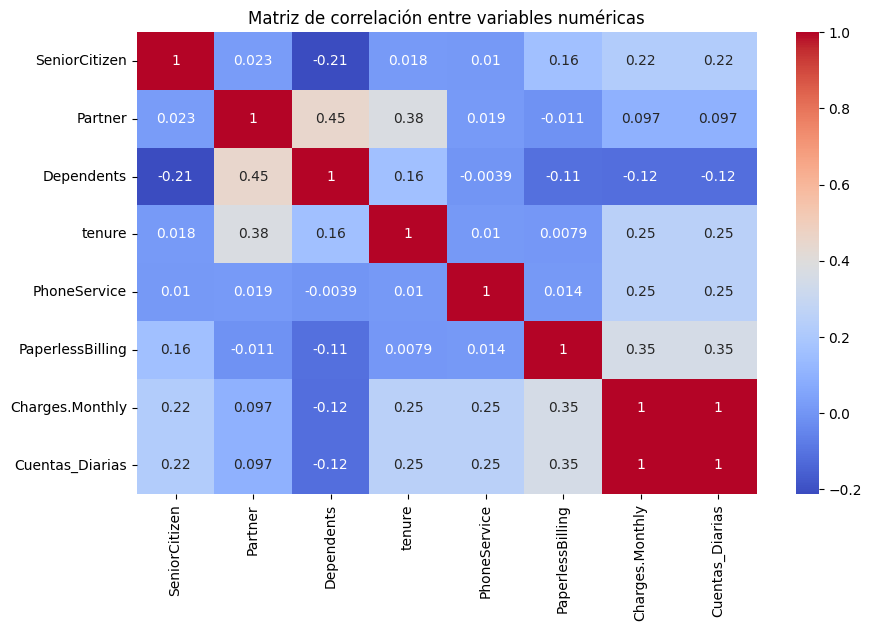

In [171]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df_final.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Matriz de correlación entre variables numéricas")
plt.show()

### Análisis de correlación

Como análisis adicional, se exploró la correlación entre variables numéricas del dataset utilizando la función `corr()` de pandas.

La matriz de correlación permite identificar qué variables tienen mayor relación entre sí y cuáles podrían influir en la evasión de clientes (Churn). Este tipo de análisis es útil como paso previo para la construcción de modelos predictivos.

In [172]:
df_final.to_csv("telecomx_parte1_limpio.csv", index=False)

In [173]:
from google.colab import files
files.download("telecomx_parte1_limpio.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [174]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [175]:
df_final.to_csv('/content/drive/MyDrive/Colab Notebooks/telecomx_parte1_limpio.csv', index=False)

##**TelecomX_parte2_Latam**

###**Extracción del Archivo Tratado**

In [176]:
from google.colab import files
files.download("telecomx_parte1_limpio.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [177]:
import pandas as pd

url = "https://raw.githubusercontent.com/js-garcia/Challenge-TelecomX/main/telecomx_parte1_limpio%20(1).csv"
df_final = pd.read_csv(url)
df_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.3,2.186667
1,0003-MKNFE,No,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.4,1.996667
2,0004-TLHLJ,Yes,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.4,2.796667


In [178]:
df_final["Churn"].unique()

array(['No', 'Yes', nan], dtype=object)

In [179]:
df_final["Churn"].value_counts(dropna=False)

,count
Churn,
No,5174
Yes,1869
NaN,224


##**Eliminación de Columnas Irrelevantes**


#### Elimina columnas que no aportan valor al análisis o a los modelos predictivos, como identificadores únicos (por ejemplo, el ID del cliente). Estas columnas no ayudan en la predicción de la cancelación y pueden incluso perjudicar el desempeño de los modelos.

In [180]:
df_final = df_final.drop(columns=["customerID"])

In [181]:
df_final.columns

Index(['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias'],
      dtype='object')

##**Encoding**

####Transforma las variables categóricas a formato numérico para hacerlas compatibles con los algoritmos de machine learning. Utiliza un método de codificación adecuado, como one-hot encoding.

In [182]:
df_final.dtypes

,0
Churn,object
gender,object
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [183]:
df_final["Charges.Total"] = pd.to_numeric(df_final["Charges.Total"], errors="coerce")

In [184]:
df_final["Charges.Total"].dtype

dtype('float64')

In [185]:
df_final.select_dtypes(include="object").columns

Index(['Churn', 'gender', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaymentMethod'],
      dtype='object')

In [186]:
df_encoded = pd.get_dummies(
    df_final,
    columns=[
        "gender", "MultipleLines", "InternetService", "OnlineSecurity",
        "OnlineBackup", "DeviceProtection", "TechSupport",
        "StreamingTV", "StreamingMovies", "Contract", "PaymentMethod"
    ],
    drop_first=True
)

In [187]:
df_encoded.head()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,Cuentas_Diarias,...,TechSupport_No internet service,StreamingTV_1,StreamingTV_No internet service,StreamingMovies_1,StreamingMovies_No internet service,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,No,0,1,1,9,1,1,65.6,593.30,2.186667,...,False,True,False,False,False,True,False,False,False,True
1,No,0,0,0,9,1,0,59.9,542.40,1.996667,...,False,False,False,True,False,False,False,False,False,True
2,Yes,0,0,0,4,1,1,73.9,280.85,2.463333,...,False,False,False,False,False,False,False,False,True,False
3,Yes,1,1,0,13,1,1,98.0,1237.85,3.266667,...,False,True,False,True,False,False,False,False,True,False
4,Yes,1,1,0,3,1,1,83.9,267.40,2.796667,...,False,True,False,False,False,False,False,False,False,True


In [188]:
df_encoded["Churn"] = df_encoded["Churn"].map({"No": 0, "Yes": 1})

In [189]:
df_encoded["Churn"].value_counts(dropna=False)

,count
Churn,
0.0,5174
1.0,1869
NaN,224


In [190]:
df_encoded = df_encoded.dropna(subset=["Churn"])

In [191]:
df_encoded["Churn"].value_counts(dropna=False)

,count
Churn,
0.0,5174
1.0,1869


In [192]:
df_encoded.dtypes


,0
Churn,float64
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
PaperlessBilling,int64
Charges.Monthly,float64
Charges.Total,float64
Cuentas_Diarias,float64


In [193]:
bool_cols = df_encoded.select_dtypes(include="bool").columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

In [194]:
df_encoded.dtypes

,0
Churn,float64
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
PaperlessBilling,int64
Charges.Monthly,float64
Charges.Total,float64
Cuentas_Diarias,float64


##**Verificación de la Proporción de Cancelación (Churn)**

In [195]:
df_encoded["Churn"].value_counts()


,count
Churn,
0.0,5174
1.0,1869


In [196]:
df_encoded["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
0.0,73.463013
1.0,26.536987


In [197]:
proporcion = df_encoded["Churn"].value_counts(normalize=True) * 100
proporcion.index = ["Permanece", "Cancela"]  # solo si 0 aparece antes que 1
proporcion

,proportion
Permanece,73.463013
Cancela,26.536987


La variable objetivo presenta un desbalance moderado entre las clases. Aproximadamente el 73,46% de los clientes permanece activo, mientras que el 26,54% canceló el servicio. Aunque la clase mayoritaria es claramente la de permanencia, la proporción de cancelación sigue siendo significativa. Este desbalance debe tenerse en cuenta en la etapa de modelado, ya que puede influir en el desempeño de los algoritmos y en la interpretación de métricas de evaluación.

##Normalización o Estandarización (si es necesario)

La necesidad de normalizar o estandarizar los datos depende del tipo de modelo utilizado. Los algoritmos basados en distancia o en optimización, como KNN, SVM y Regresión Logística, suelen requerir que las variables estén en escalas comparables


In [198]:
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

In [199]:
X.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,Cuentas_Diarias,gender_Male,...,TechSupport_No internet service,StreamingTV_1,StreamingTV_No internet service,StreamingMovies_1,StreamingMovies_No internet service,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,1,9,1,1,65.6,593.30,2.186667,0,...,0,1,0,0,0,1,0,0,0,1
1,0,0,0,9,1,0,59.9,542.40,1.996667,1,...,0,0,0,1,0,0,0,0,0,1
2,0,0,0,4,1,1,73.9,280.85,2.463333,1,...,0,0,0,0,0,0,0,0,1,0
3,1,1,0,13,1,1,98.0,1237.85,3.266667,1,...,0,1,0,1,0,0,0,0,1,0
4,1,1,0,3,1,1,83.9,267.40,2.796667,0,...,0,1,0,0,0,0,0,0,0,1


In [200]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [201]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4930, 31)
X_test: (2113, 31)
y_train: (4930,)
y_test: (2113,)


In [202]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [203]:
X_train_scaled[:5]

array([[-0.43781822, -0.96217527, -0.65939966, -0.75333321,  0.31499146,
        -1.22474487,  0.37629515, -0.52236114,  0.37629515,  0.98031541,
        -0.85714286, -0.31499146,  1.1144183 , -0.52429962, -0.63227593,
        -0.52429962, -0.72319785, -0.52429962,  1.38274746, -0.52429962,
        -0.64234527, -0.52429962, -0.79289044, -0.52429962, -0.80003327,
        -0.52429962, -0.51926571, -0.56407607, -0.52775655,  1.41636774,
        -0.54061758],
       [-0.43781822, -0.96217527, -0.65939966, -1.119298  ,  0.31499146,
         0.81649658,  0.16225067, -0.85942089,  0.16225067,  0.98031541,
        -0.85714286, -0.31499146, -0.89732913, -0.52429962, -0.63227593,
        -0.52429962, -0.72319785, -0.52429962,  1.38274746, -0.52429962,
        -0.64234527, -0.52429962,  1.26120829, -0.52429962,  1.24994802,
        -0.52429962,  1.92579633, -0.56407607, -0.52775655, -0.70603133,
         1.84973638],
       [-0.43781822,  1.03931168, -0.65939966,  0.10058464,  0.31499146,
       

##**🎯 Correlación y Selección de Variables**

####**Análisis de Correlación**

Visualiza la matriz de correlación para identificar relaciones entre las variables numéricas. Presta especial atención a las variables que muestran una mayor correlación con la cancelación, ya que estas pueden ser fuertes candidatas para el modelo predictivo.

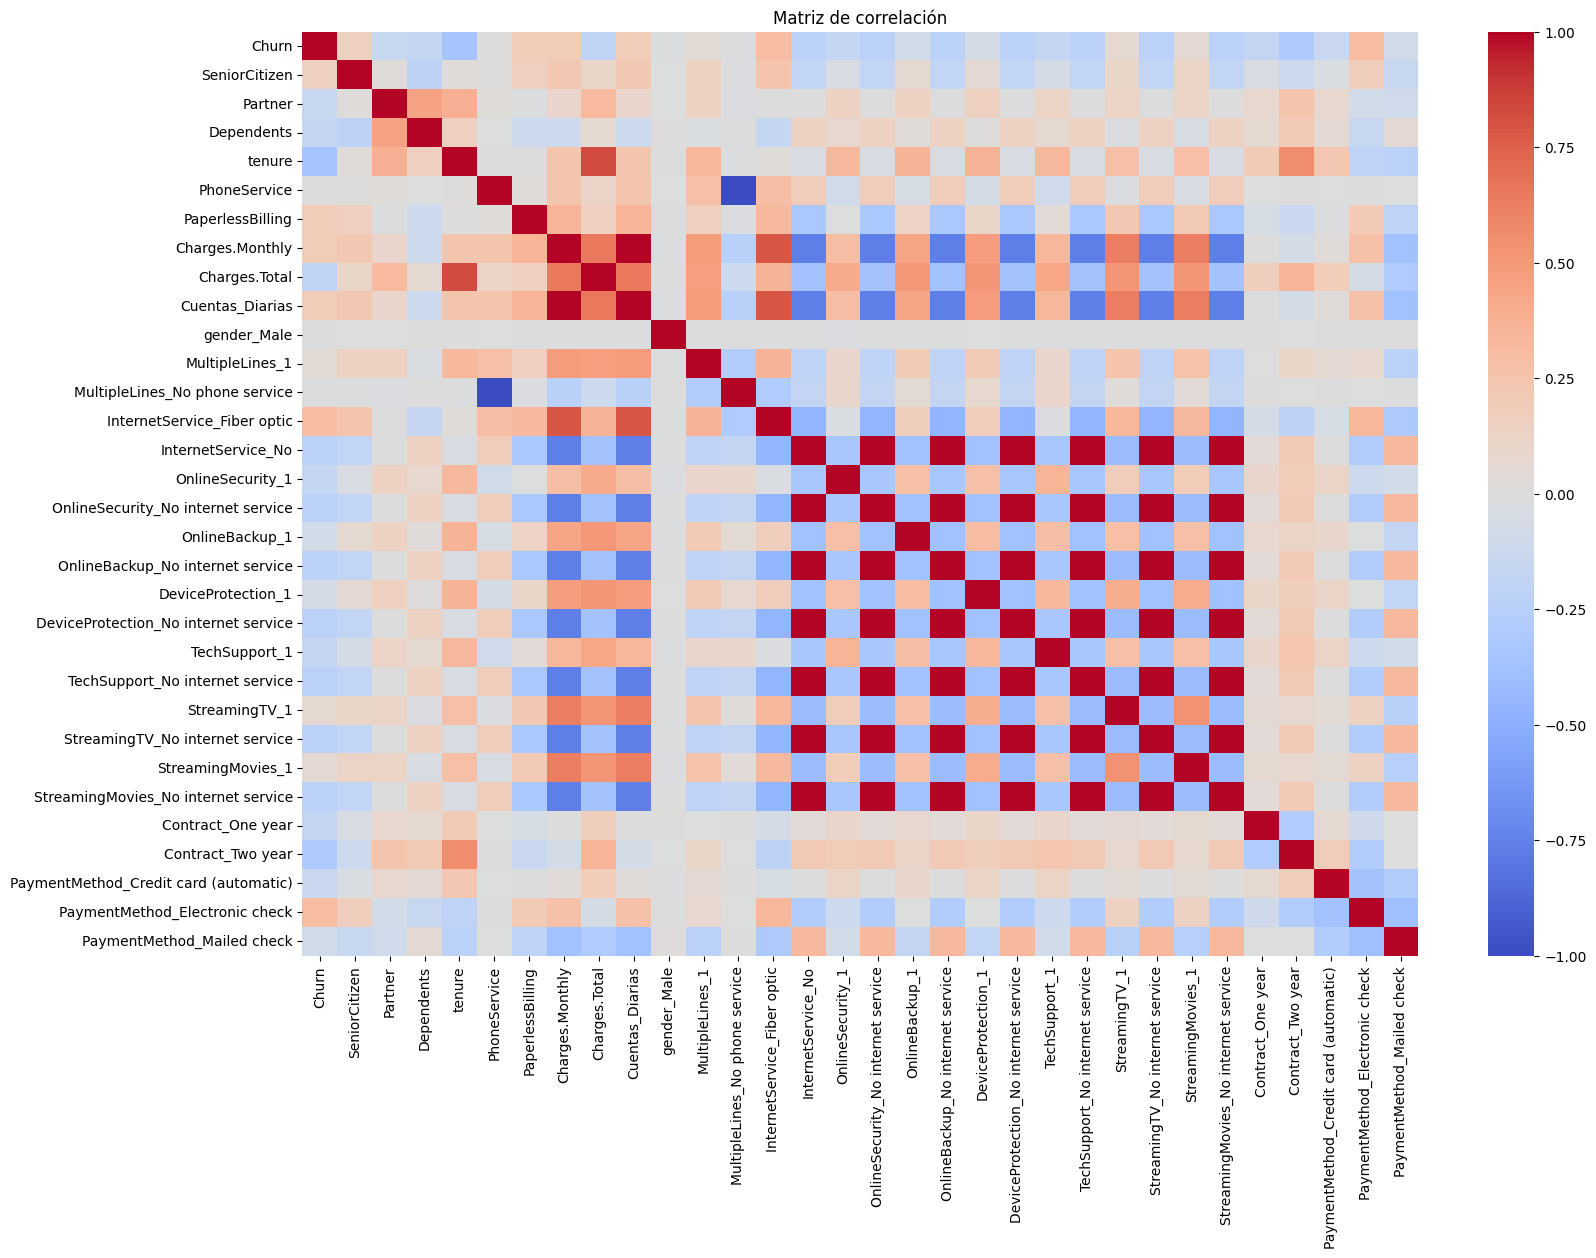

In [204]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 12))
sns.heatmap(df_encoded.corr(), cmap="coolwarm", annot=False)
plt.title("Matriz de correlación")
plt.show()

In [205]:
corr_churn = df_encoded.corr()["Churn"].sort_values(ascending=False)
corr_churn

,Churn
Churn,1.000000
InternetService_Fiber optic,0.308020
PaymentMethod_Electronic check,0.301919
Charges.Monthly,0.193356
Cuentas_Diarias,0.193356
PaperlessBilling,0.191825
SeniorCitizen,0.150889
StreamingTV_1,0.063228
StreamingMovies_1,0.061382
MultipleLines_1,0.040102


##**Análisis Dirigido**


Descripción
Editar
Investiga cómo variables específicas se relacionan con la cancelación, tales como:

Tiempo de contrato × Cancelación

Gasto total × Cancelación

Utiliza gráficos como boxplots o scatter plots para visualizar patrones y posibles tendencias.


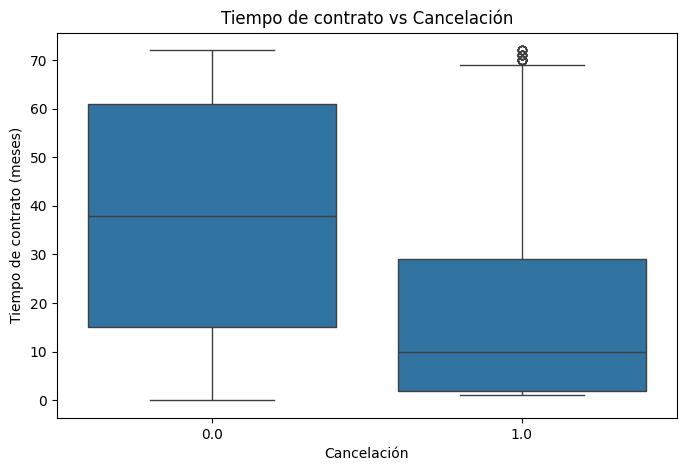

In [206]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Churn", y="tenure", data=df_encoded)
plt.title("Tiempo de contrato vs Cancelación")
plt.xlabel("Cancelación")
plt.ylabel("Tiempo de contrato (meses)")
plt.show()

El boxplot muestra la relación entre la antigüedad del cliente y la cancelación. Se observa que los clientes que cancelaron tienden a presentar menores valores de tenure, lo que sugiere que la cancelación es más frecuente entre clientes con menor tiempo de permanencia en la empresa.

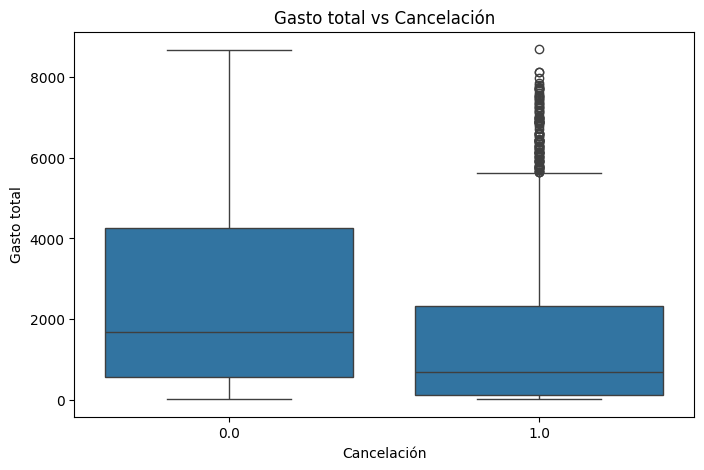

In [207]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Churn", y="Charges.Total", data=df_encoded)
plt.title("Gasto total vs Cancelación")
plt.xlabel("Cancelación")
plt.ylabel("Gasto total")
plt.show()

El boxplot de Charges.Total en función de la cancelación muestra que los clientes que permanecen en la empresa tienden a registrar un gasto total más alto, mientras que quienes cancelan suelen concentrarse en valores más bajos. Esto es coherente con el análisis de tenure, ya que los clientes con mayor permanencia acumulan un gasto total más elevado y presentan menor probabilidad de cancelación.

##**🤖 Modelado Predictivo**

####**Separación de Datos**

Para evaluar el rendimiento de los modelos predictivos, el conjunto de datos se dividió en dos partes: entrenamiento y prueba. Se utilizó una proporción de 70% para entrenamiento y 30% para prueba, manteniendo la distribución de la variable objetivo mediante stratify, lo que permite una evaluación más confiable del modelo.

In [208]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4930, 31)
X_test: (2113, 31)
y_train: (4930,)
y_test: (2113,)


In [209]:
mediana_total = X_train["Charges.Total"].median()

X_train.loc[:, "Charges.Total"] = X_train["Charges.Total"].fillna(mediana_total)
X_test.loc[:, "Charges.Total"] = X_test["Charges.Total"].fillna(mediana_total)

In [210]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

####**Creación de Modelos**

In [211]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [212]:
y_pred_log = log_model.predict(X_test_scaled)

In [213]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [214]:
y_pred_rf = rf_model.predict(X_test)

In [215]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Regresión Logística")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Regresión Logística
Accuracy: 0.7983909133932797
[[1382  170]
 [ 256  305]]
              precision    recall  f1-score   support

         0.0       0.84      0.89      0.87      1552
         1.0       0.64      0.54      0.59       561

    accuracy                           0.80      2113
   macro avg       0.74      0.72      0.73      2113
weighted avg       0.79      0.80      0.79      2113



In [216]:
print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest
Accuracy: 0.7832465688594415
[[1380  172]
 [ 286  275]]
              precision    recall  f1-score   support

         0.0       0.83      0.89      0.86      1552
         1.0       0.62      0.49      0.55       561

    accuracy                           0.78      2113
   macro avg       0.72      0.69      0.70      2113
weighted avg       0.77      0.78      0.77      2113



[[1380  172]
 [ 286  275]]


1380 clientes que no cancelaron fueron clasificados correctamente.

172 clientes que no cancelaron fueron clasificados como si cancelaran.

286 clientes que sí cancelaron no fueron detectados por el modelo.

275 clientes que sí cancelaron fueron detectados correctamente.

El modelo Random Forest obtuvo una accuracy de 78,3%, mostrando un buen desempeño general. Presentó mejores resultados para identificar a los clientes que permanecen activos, con un recall de 89% para la clase 0. Sin embargo, su capacidad para detectar clientes que cancelan fue más limitada, con un recall de 49% para la clase 1. Esto indica que, aunque el modelo funciona razonablemente bien en términos generales, todavía deja escapar una proporción importante de clientes con riesgo de churn.

###**Evaluación de los Modelos**

In [218]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("Regresión Logística")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Regresión Logística
Accuracy: 0.7983909133932797
Precision: 0.6421052631578947
Recall: 0.5436720142602496
F1-score: 0.5888030888030888
[[1382  170]
 [ 256  305]]
              precision    recall  f1-score   support

         0.0       0.84      0.89      0.87      1552
         1.0       0.64      0.54      0.59       561

    accuracy                           0.80      2113
   macro avg       0.74      0.72      0.73      2113
weighted avg       0.79      0.80      0.79      2113



In [219]:
print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest
Accuracy: 0.7832465688594415
Precision: 0.6152125279642058
Recall: 0.49019607843137253
F1-score: 0.5456349206349206
[[1380  172]
 [ 286  275]]
              precision    recall  f1-score   support

         0.0       0.83      0.89      0.86      1552
         1.0       0.62      0.49      0.55       561

    accuracy                           0.78      2113
   macro avg       0.72      0.69      0.70      2113
weighted avg       0.77      0.78      0.77      2113



El modelo Random Forest obtuvo una exactitud de 78,3%, con una precisión de 62% para la clase de cancelación, un recall de 49% y un F1-score de 55%. Esto indica que el modelo logra un buen rendimiento general, especialmente para identificar clientes que permanecen activos. Sin embargo, su capacidad para detectar clientes que cancelan todavía es moderada, ya que deja sin identificar una parte importante de los casos reales de churn.

A partir de los resultados observados en el conjunto de prueba, no se detecta evidencia concluyente de underfitting extremo, ya que el modelo logra capturar patrones relevantes y obtiene un desempeño aceptable. Sin embargo, tampoco puede descartarse cierto sobreajuste sin comparar explícitamente el rendimiento en entrenamiento y prueba. En modelos como Random Forest, un desempeño mucho mejor en entrenamiento que en prueba podría indicar overfitting, lo que podría corregirse ajustando hiperparámetros como la profundidad de los árboles, el número mínimo de muestras por hoja o la cantidad de estimadores.

##**📋 Interpretación y Conclusiones**

###**Análisis de la Importancia de las Variables**

In [220]:
coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": log_model.coef_[0]
})

coeficientes["Valor absoluto"] = coeficientes["Coeficiente"].abs()
coeficientes = coeficientes.sort_values(by="Valor absoluto", ascending=False)

coeficientes.head(10)

,Variable,Coeficiente,Valor absoluto
3,tenure,-1.434015,1.434015
7,Charges.Total,0.681123,0.681123
12,InternetService_Fiber optic,0.615406,0.615406
27,Contract_Two year,-0.567966,0.567966
8,Cuentas_Diarias,-0.310641,0.310641
6,Charges.Monthly,-0.310641,0.310641
26,Contract_One year,-0.303612,0.303612
5,PaperlessBilling,0.202058,0.202058
22,StreamingTV_1,0.193887,0.193887
10,MultipleLines_1,0.175602,0.175602


En la Regresión Logística, la variable más influyente fue tenure, con un coeficiente negativo elevado, lo que indica que a mayor antigüedad del cliente, menor probabilidad de cancelación. También se destacaron Contract_Two year y Contract_One year, ambas con coeficientes negativos, reforzando la idea de que los contratos más largos favorecen la permanencia.

Entre las variables asociadas positivamente con la cancelación se encontraron InternetService_Fiber optic, Charges.Total, PaperlessBilling, StreamingTV_1 y MultipleLines_1. Esto sugiere que ciertos perfiles de servicio y facturación están más relacionados con el churn.

In [221]:
importancias_rf = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": rf_model.feature_importances_
}).sort_values(by="Importancia", ascending=False)

importancias_rf.head(10)

,Variable,Importancia
7,Charges.Total,0.165230
3,tenure,0.162013
6,Charges.Monthly,0.130508
8,Cuentas_Diarias,0.127808
29,PaymentMethod_Electronic check,0.033657
27,Contract_Two year,0.031604
12,InternetService_Fiber optic,0.031371
9,gender_Male,0.024907
5,PaperlessBilling,0.023932
20,TechSupport_1,0.022001


En el modelo Random Forest, las variables más relevantes para la predicción fueron Charges.Total, tenure, Charges.Monthly y Cuentas_Diarias, lo que indica que el comportamiento de consumo y la permanencia del cliente son factores centrales para explicar la cancelación.

También se destacaron variables como PaymentMethod_Electronic check, Contract_Two year, InternetService_Fiber optic, PaperlessBilling y TechSupport_1, lo que sugiere que tanto las condiciones contractuales como el tipo de servicio y la forma de pago influyen en la probabilidad de churn.

###**Conclusión**

Conclusión final

A partir del análisis realizado, se observó que la cancelación de clientes en Telecom X está principalmente asociada con la antigüedad del cliente, el tipo de contrato, el tipo de servicio de internet, el método de pago y las variables vinculadas al nivel de gasto, como Charges.Total y Charges.Monthly.

Los resultados mostraron que los clientes con menor tiempo de permanencia, contratos más cortos y ciertas características de servicio, como fibra óptica y pago mediante cheque electrónico, presentan mayor probabilidad de cancelar. En cambio, los clientes con mayor antigüedad y contratos de uno o dos años tienden a permanecer en la empresa.

En cuanto a los modelos, ambos permitieron identificar patrones relevantes para predecir churn. Random Forest mostró un rendimiento general aceptable, aunque con dificultades para detectar todos los casos reales de cancelación, lo que indica que todavía hay margen de mejora en la predicción de la clase minoritaria.

A nivel estratégico, Telecom X podría enfocar sus acciones de retención en los primeros meses de relación con el cliente, ofrecer incentivos para contratos de mayor duración, revisar la experiencia de quienes utilizan fibra óptica y diseñar campañas específicas para clientes con mayor riesgo de cancelación según su perfil de pago y consumo.

En conclusión, el uso de modelos predictivos permitió transformar los datos en información útil para anticipar la cancelación y apoyar la toma de decisiones orientadas a la fidelización de clientes.